**Simple Concept**

Model Error Analysis means studying the images that a CNN predicts incorrectly to understand **why the model made a mistake**.

For example, suppose we train a CNN to classify images of cats and dogs.

- Actual class: Cat
- Model prediction: Dog
- Result: Wrong prediction

Error analysis helps us investigate the possible reason. Maybe the image is blurry, the cat is partially hidden, or the cat looks similar to a dog in that image.

**Why is it needed?**

Instead of simply counting wrong predictions, we identify patterns in the mistakes and decide how to improve the model.

**Real-World Example**

A CNN correctly identifies most clear cat images but frequently mistakes blurry cat images for dogs. Error analysis reveals that image quality may be affecting its predictions.

**Key Point**

Model Error Analysis = Identify mistakes → Find possible causes → Propose improvements.

A wrong prediction alone does not tell us the cause. We must investigate the image and compare it with other errors to identify likely patterns.

In [1]:
actual_label = "Cat"
predicted_label = "Dog"

if actual_label == predicted_label:
    print("Correct prediction")
else:
    print("Wrong prediction")
    print("Actual class:", actual_label)
    print("Predicted class:", predicted_label)

Wrong prediction
Actual class: Cat
Predicted class: Dog


**Simple Concept**

Analyzing errors by class means checking which image classes the CNN predicts incorrectly most often.

For example, suppose a CNN classifies images into three classes: Cat, Dog, and Horse.

- Cat images: 5 wrong predictions
- Dog images: 15 wrong predictions
- Horse images: 3 wrong predictions

Here, Dog has the highest number of incorrect predictions.

We should investigate why the model struggles with Dog images.

**Why is it needed?**

It helps us identify which classes need more attention during model improvement.

**Real-World Example**

A CNN classifies cats and dogs. It correctly identifies most cats but frequently predicts dogs as cats because some images contain similar visual features.

We can inspect the misclassified dog images and investigate whether the classes look similar, the dataset has insufficient examples, or the model has learned poor features.

**Key Point**

Error analysis by class helps us identify which classes have more prediction mistakes. However, we should also consider how many images belong to each class.

In [2]:
from sklearn.metrics import confusion_matrix, classification_report

actual = ["Cat", "Dog", "Dog", "Cat", "Horse",
          "Dog", "Horse", "Cat", "Dog", "Horse"]

predicted = ["Cat", "Cat", "Dog", "Cat", "Dog",
             "Dog", "Horse", "Dog", "Cat", "Horse"]

print(classification_report(
    actual,
    predicted,
    zero_division=0
))

              precision    recall  f1-score   support

         Cat       0.50      0.67      0.57         3
         Dog       0.50      0.50      0.50         4
       Horse       1.00      0.67      0.80         3

    accuracy                           0.60        10
   macro avg       0.67      0.61      0.62        10
weighted avg       0.65      0.60      0.61        10



What does this code do?
- actual: the correct class labels.
- predicted: the labels predicted by the CNN.
- classification_report(): shows precision, recall, F1-score, and support for each class.
- support: the number of actual images belonging to each class.
Important: A class with more mistakes does not always have a worse model performance. Compare the number of mistakes with the total number of images in each class.

# Topic 3: Analyzing Errors by Image Quality
**Simple Concept**

Image quality analysis means checking whether the CNN makes more mistakes when images are blurry, dark, or unclear.

Common image-quality problems include:

- **Blurry images:** Objects have unclear edges.
- **Dark images:** Objects are difficult to see.
- **Low-resolution images:** Important details are missing.
- **Overexposed images:** Images are too bright, hiding details.

**Why is it needed?**

A CNN learns patterns from images. When important patterns are unclear, the model may struggle to identify the correct object.

**Real-World Example**

A CNN correctly identifies a clear image of a dog but predicts a blurry dog image as a cat because the dog's facial features and body shape are difficult to recognize.

**Possible Improvements**

- Collect clearer training images.
- Include realistic blurry and low-light images in training.
- Apply suitable image preprocessing.
- Check whether image enhancement improves predictions.

**Key Point**

If wrong predictions occur more frequently on poor-quality images, image quality may be contributing to the errors. We must examine multiple images before concluding that it is the main cause.

File exists: True


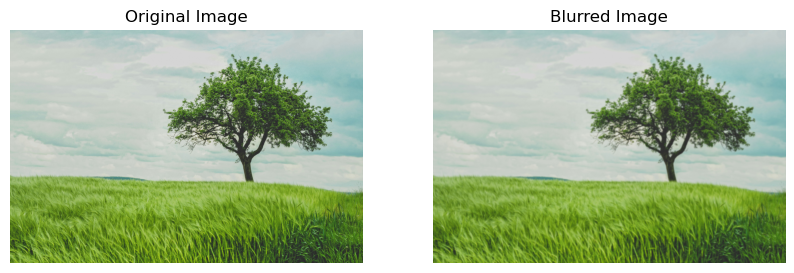

In [17]:

from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
import os

image_path = r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"

print("File exists:", os.path.exists(image_path))

image = Image.open(image_path)

blurred_image = image.filter(ImageFilter.GaussianBlur(radius=5))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_image)
plt.title("Blurred Image")
plt.axis("off")

plt.show()


**Image Size Analysis** means checking whether the CNN makes more mistakes when images are too small or contain very little detail.

When an image is resized to a very small size, important details may disappear. For example, a rabbit's ears or facial features may become difficult to recognize.

**Why is image size important?**

- Small images may lose important details.
- Large images may preserve details but require more computation.
- Resizing images too much may reduce classification accuracy.

**Real-world example:** A CNN correctly identifies a rabbit in a high-resolution image but mistakes it for a cat when the rabbit appears very small in the image.

**Possible improvement:** Test suitable input sizes and compare the model's errors. Use a size that preserves important details without unnecessary computation.

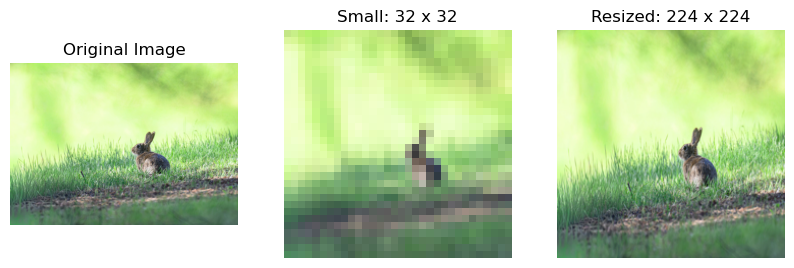

In [19]:

from PIL import Image
import matplotlib.pyplot as plt

image_path = r"C:\Users\nanda\Downloads\rabbit.jpg"

image = Image.open(image_path).convert("RGB")

small_image = image.resize((32, 32))
large_image = image.resize((224, 224))

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(small_image)
plt.title("Small: 32 x 32")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(large_image)
plt.title("Resized: 224 x 224")
plt.axis("off")

plt.show()


Python explanation:
- Image.open() loads your rabbit image.
- convert("RGB") ensures the image has three color channels.
- resize((32, 32)) reduces the image size.
- resize((224, 224)) resizes it to a larger standard input size.
- plt.imshow() displays each image for comparison.
Important: This code compares image sizes visually; it does not measure CNN accuracy. To determine whether size causes classification errors, evaluate the model on images processed at different sizes.

**Orientation Analysis** means checking whether a CNN makes incorrect predictions when an image is rotated, tilted, or captured from an unusual angle.

A CNN may learn to recognize an object in a familiar orientation but struggle when the same object appears at a different angle.

**Why is orientation important?**

- Objects may appear rotated or tilted.
- Important features may look different from the training images.
- The model may not have seen enough examples from different angles.

**Real-world example:** A CNN correctly identifies a rabbit standing upright but mistakes it for another animal when the rabbit is photographed from a sideways angle.

**Possible improvement:** Include suitable rotated or differently oriented training images through data augmentation. However, rotations should be realistic for the task.

**Important:** A rotation does not always cause a prediction error. We need to test the model to determine whether orientation affects its performance.

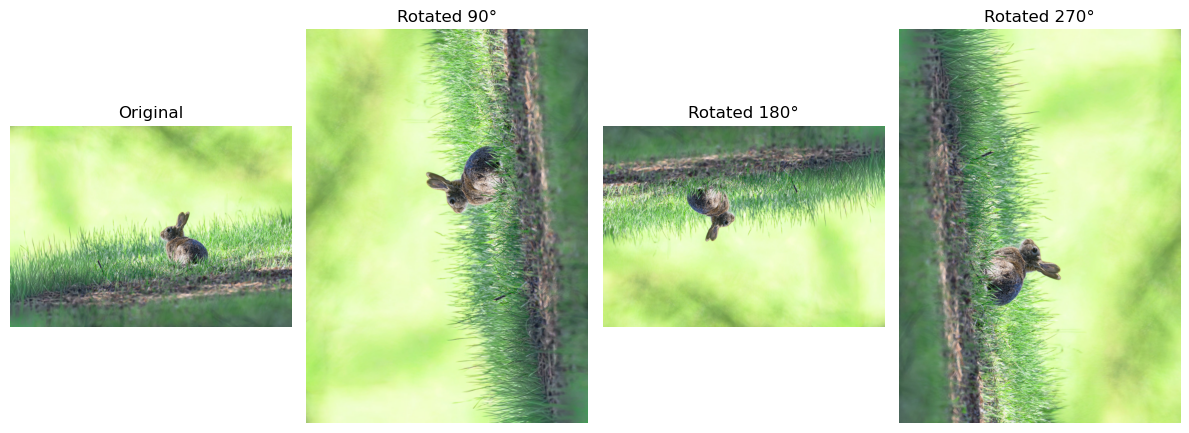

In [20]:

from PIL import Image
import matplotlib.pyplot as plt

image_path = r"C:\Users\nanda\Downloads\rabbit.jpg"

image = Image.open(image_path).convert("RGB")

rotated_90 = image.rotate(90, expand=True)
rotated_180 = image.rotate(180, expand=True)
rotated_270 = image.rotate(270, expand=True)

images = [
    image,
    rotated_90,
    rotated_180,
    rotated_270
]

titles = [
    "Original",
    "Rotated 90°",
    "Rotated 180°",
    "Rotated 270°"
]

plt.figure(figsize=(12, 5))

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


Python explanation
- Image.open() loads the rabbit image.
- rotate(90) rotates the image by 90 degrees.
- expand=True adjusts the output dimensions to fit the rotated image.
- The images and titles lists store the images and their labels.
- The for loop displays all four versions for comparison.
Note: This code visualizes orientation changes; it does not run the CNN or measure prediction accuracy.

**Background Analysis** means checking whether a CNN makes incorrect predictions because of the surroundings behind the main object.

A CNN may learn patterns from the background instead of focusing only on the object itself.

**Why is background important?**

- The background may contain distracting objects.
- The object may blend into the background.
- The model may learn an unwanted relationship between a class and its usual background.

**Real-world example:** A CNN correctly identifies rabbits photographed on grass but makes mistakes when rabbits appear on sand or indoors.

**Possible improvement:** Train the model using images with varied backgrounds. You can also inspect whether the model focuses on the object or the surrounding area.

**Important:** A different background does not automatically cause an error. Compare correct and incorrect predictions to identify a possible pattern.

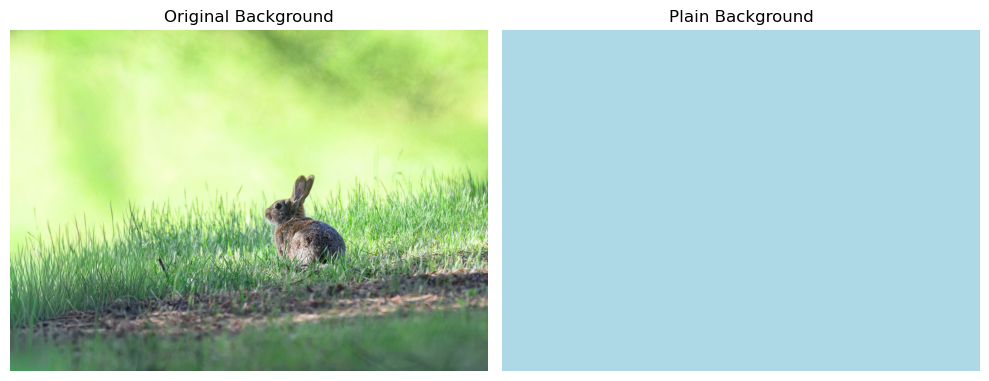

In [21]:

from PIL import Image
import matplotlib.pyplot as plt

image_path = r"C:\Users\nanda\Downloads\rabbit.jpg"

image = Image.open(image_path).convert("RGB")

# Display the original image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Background")
plt.axis("off")

# Create a plain background for comparison
plain_background = Image.new("RGB", image.size, "lightblue")

plt.subplot(1, 2, 2)
plt.imshow(plain_background)
plt.title("Plain Background")
plt.axis("off")

plt.tight_layout()
plt.show()


Python explanation
- Image.open() loads the rabbit image.
- Image.new() creates a new image with a plain light-blue background.
- plt.imshow() displays the images.
Note: This example does not remove the rabbit from its original background or combine it with the new background. Proper background replacement requires separating the rabbit from its surroundings using image segmentation or a mask.

**Similar-Looking Class Analysis** means checking whether a CNN confuses two classes because they share similar visual features.

For example, a CNN may confuse a rabbit with a cat because both animals have fur, ears, eyes, and similar facial features.

**Why does this happen?**

- Different classes may share similar shapes or textures.
- Important distinguishing features may be small or unclear.
- The training dataset may not contain enough examples showing the differences.

**Real-world example:** A CNN predicts a cat when the actual image contains a rabbit. When we inspect the image, we find that the rabbit's face is partially hidden, making it difficult to distinguish the animals.

**Possible improvement:** Add more representative training images, improve image quality where possible, and examine which classes are most frequently confused.

**Important:** The actual label tells us what the object is; the predicted label tells us what the model thinks it is. Comparing them helps us identify class confusion.

In [22]:

import matplotlib.pyplot as plt

actual_labels = ["Rabbit", "Cat", "Rabbit", "Dog", "Cat"]
predicted_labels = ["Rabbit", "Rabbit", "Cat", "Dog", "Rabbit"]

for i in range(len(actual_labels)):
    if actual_labels[i] != predicted_labels[i]:
        print(
            f"Image {i + 1}: "
            f"Actual = {actual_labels[i]}, "
            f"Predicted = {predicted_labels[i]}"
        )


Image 2: Actual = Cat, Predicted = Rabbit
Image 3: Actual = Rabbit, Predicted = Cat
Image 5: Actual = Cat, Predicted = Rabbit


Python explanation
- actual_labels stores the correct classes.
- predicted_labels stores the model's predictions.
- The for loop checks every image.
- The if condition finds cases where the actual and predicted classes differ.
- print() displays the incorrect predictions.
What does this tell us?
The model confuses rabbits and cats in these examples. This suggests a possible class-confusion pattern, but we must inspect the images to determine whether visual similarity is the cause.

**Occlusion Analysis** means checking whether a CNN makes incorrect predictions when an important part of an object is hidden or blocked.

For example, if a rabbit's face or ears are covered by grass, the CNN may struggle to identify it correctly.

**Why does occlusion cause errors?**

- Important object features may be hidden.
- The model receives incomplete visual information.
- The remaining visible features may resemble another class.

**Real-world example:** A CNN correctly identifies a rabbit when its entire body is visible but predicts a cat when the rabbit is partially hidden behind a tree.

**Possible improvement:** Train the model with suitable examples of partially hidden objects. Data augmentation can simulate occlusion, but the hidden region should not remove all the important information.

**Important:** Occlusion does not always cause a wrong prediction. Some models can identify objects from the features that remain visible.

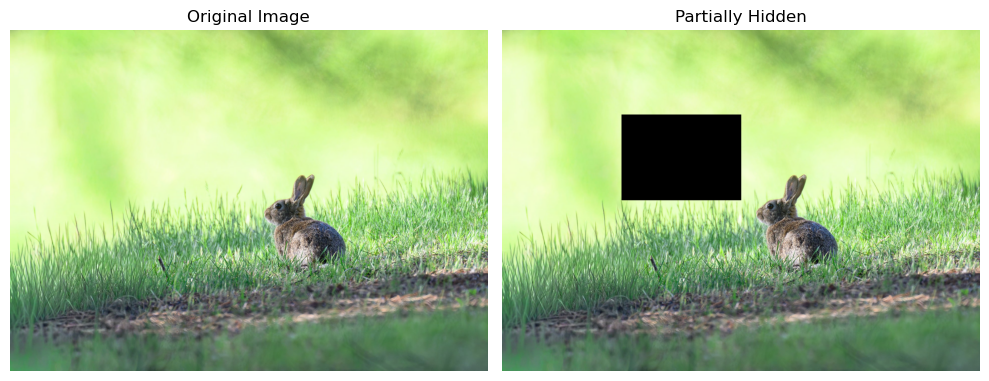

In [23]:

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

image_path = r"C:\Users\nanda\Downloads\rabbit.jpg"

image = Image.open(image_path).convert("RGB")

# Create a copy
occluded_image = image.copy()

# Draw a black rectangle over part of the image
draw = ImageDraw.Draw(occluded_image)

width, height = occluded_image.size

draw.rectangle(
    (width // 4, height // 4,
     width // 2, height // 2),
    fill="black"
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(occluded_image)
plt.title("Partially Hidden")
plt.axis("off")

plt.tight_layout()
plt.show()


Python explanation
- image.copy() creates a separate copy so the original remains unchanged.
- ImageDraw.Draw() lets us draw on the copied image.
- width and height retrieve the image dimensions.
- draw.rectangle() covers part of the image with black.
- plt.imshow() displays the original and occluded images side by side.
What does this example tell us?
We can visually inspect how hiding part of an object changes the available information. To determine whether occlusion affects classification, we must also run the original and modified images through a trained CNN and compare their predictions.

**Noise Analysis** means checking whether a CNN makes incorrect predictions when an image contains unwanted visual disturbances, such as random dots, grain, or sensor interference.

Noise can make important object features harder to recognize.

**Why does noise cause errors?**

- It hides or distorts important visual details.
- It makes edges and textures less clear.
- Heavy noise can make different classes look more similar.

**Real-world example:** A CNN correctly identifies a rabbit in a clear photograph but misclassifies it when the photograph is grainy because it was captured in low light.

**Possible improvement:** Train with realistic noisy images, use suitable image-denoising techniques, and test the model under different noise levels.

**Important:** A small amount of noise may not affect predictions. We should test the model to understand how sensitive it is to noise.

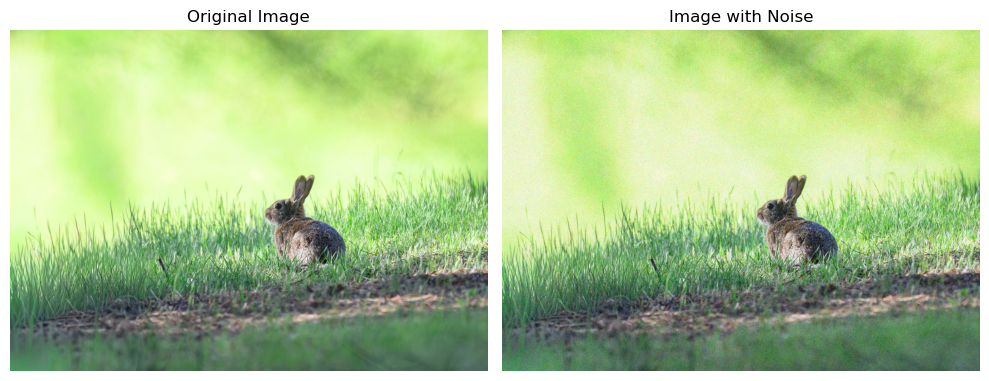

In [24]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image_path = r"C:\Users\nanda\Downloads\rabbit.jpg"

image = Image.open(image_path).convert("RGB")

# Convert image to a NumPy array
image_array = np.array(image).astype(np.float32)

# Generate random noise
np.random.seed(42)
noise = np.random.normal(
    loc=0,
    scale=25,
    size=image_array.shape
)

# Add noise and keep pixel values between 0 and 255
noisy_array = np.clip(
    image_array + noise, 0, 255
).astype(np.uint8)

noisy_image = Image.fromarray(noisy_array)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_image)
plt.title("Image with Noise")
plt.axis("off")

plt.tight_layout()
plt.show()


Python explanation
- np.array(image) converts the image into numerical pixel values.
- np.random.normal() generates random noise.
- scale=25 controls the strength of the noise; larger values generally create more visible noise.
- np.clip() keeps pixel values within the valid range of 0–255.
- Image.fromarray() converts the noisy array back into an image.
- plt.imshow() displays both versions for comparison.
What does this example tell us?
We can see how noise changes the image. However, this code does not classify the images. To measure the effect on a CNN, compare its predictions on the original image and the noisy image.


## Next: Create the Error-Analysis Table

Your listed error-analysis topics are now covered: class, image quality, size, orientation, background, similar-looking classes, occlusion, and noise.

The next step is to organize the findings into your required table:

| Error Type              | Example                     | Possible Cause                          | Impact                               | Proposed Improvement                   |
| ----------------------- | --------------------------- | --------------------------------------- | ------------------------------------ | -------------------------------------- |
| Image quality           | Blurry rabbit               | Missing fine details                    | Rabbit predicted as cat              | Improve image quality                  |
| Size                    | Very small rabbit           | Important features lost during resizing | Lower recognition accuracy           | Test suitable input sizes              |
| Orientation             | Sideways rabbit             | Unfamiliar viewing angle                | Incorrect prediction                 | Use realistic rotation augmentation    |
| Background              | Rabbit on unfamiliar ground | Model may rely on background features   | Incorrect prediction in new settings | Use diverse backgrounds                |
| Similar-looking classes | Rabbit confused with cat    | Shared visual features                  | Class confusion                      | Add representative examples            |
| Occlusion               | Rabbit partly hidden        | Important features blocked              | Uncertain prediction                 | Train with partial-visibility examples |
| Noise                   | Grainy rabbit               | Distorted edges and textures            | Reduced prediction reliability       | Test noise robustness                  |

These are example findings, not measured results from your model. In a real experiment, fill the table using actual misclassified test images.

**Error-Analysis Table** organizes the mistakes made by a CNN so we can understand their possible causes and decide how to improve the model.

The table contains five columns:

- **Error Type:** The category of error, such as noise or occlusion.
- **Example:** What happened in the image.
- **Possible Cause:** Why the model might have made the mistake.
- **Impact:** How the mistake affects classification.
- **Proposed Improvement:** What we can try to reduce similar errors.

The goal is to move beyond simply counting incorrect predictions. We want to identify recurring patterns and choose improvements based on evidence.

**Important:** The causes recorded in the table are hypotheses until we test them. A wrong prediction alone does not prove why the model failed.

**Error-Analysis Table** organizes the mistakes made by a CNN so we can understand their possible causes and decide how to improve the model.

The table contains five columns:

- **Error Type:** The category of error, such as noise or occlusion.
- **Example:** What happened in the image.
- **Possible Cause:** Why the model might have made the mistake.
- **Impact:** How the mistake affects classification.
- **Proposed Improvement:** What we can try to reduce similar errors.

The goal is to move beyond simply counting incorrect predictions. We want to identify recurring patterns and choose improvements based on evidence.

**Important:** The causes recorded in the table are hypotheses until we test them. A wrong prediction alone does not prove why the model failed.

In [25]:

import pandas as pd

error_data = {
    "Error Type": [
        "Image Quality",
        "Size",
        "Orientation",
        "Background",
        "Similar Classes",
        "Occlusion",
        "Noise"
    ],
    "Example": [
        "Blurry rabbit",
        "Very small rabbit",
        "Sideways rabbit",
        "Rabbit on unfamiliar ground",
        "Rabbit predicted as cat",
        "Rabbit partly hidden",
        "Grainy rabbit"
    ],
    "Possible Cause": [
        "Fine details are unclear",
        "Important features are lost",
        "Unfamiliar viewing angle",
        "Model may rely on background",
        "Classes share visual features",
        "Important parts are blocked",
        "Image details are distorted"
    ],
    "Impact": [
        "Incorrect prediction",
        "Reduced recognition",
        "Orientation-related errors",
        "Poor performance on new backgrounds",
        "Class confusion",
        "Uncertain prediction",
        "Reduced reliability"
    ],
    "Proposed Improvement": [
        "Use clearer images",
        "Test suitable image sizes",
        "Use realistic rotation augmentation",
        "Include diverse backgrounds",
        "Add representative training images",
        "Train with partial occlusion",
        "Test noise robustness"
    ]
}

error_table = pd.DataFrame(error_data)

display(error_table)


,Error Type,Example,Possible Cause,Impact,Proposed Improvement
0,Image Quality,Blurry rabbit,Fine details are unclear,Incorrect prediction,Use clearer images
1,Size,Very small rabbit,Important features are lost,Reduced recognition,Test suitable image sizes
2,Orientation,Sideways rabbit,Unfamiliar viewing angle,Orientation-related errors,Use realistic rotation augmentation
3,Background,Rabbit on unfamiliar ground,Model may rely on background,Poor performance on new backgrounds,Include diverse backgrounds
4,Similar Classes,Rabbit predicted as cat,Classes share visual features,Class confusion,Add representative training images
5,Occlusion,Rabbit partly hidden,Important parts are blocked,Uncertain prediction,Train with partial occlusion
6,Noise,Grainy rabbit,Image details are distorted,Reduced reliability,Test noise robustness


Python explanation
- error_data stores example findings for each error category.
- Each dictionary key becomes a column name.
- pd.DataFrame(error_data) converts the dictionary into a table.
- display(error_table) displays the table in Jupyter Notebook.
What does this example tell us?
We now have a structured record of possible CNN errors and improvements. These are illustrative entries, not results measured from your trained model.
In a real project, replace the examples with observations from incorrectly classified test images.

**Improving a CNN Using Error Analysis** means using the mistakes identified during testing to decide what changes may help the model perform better.

For example, if a CNN frequently mistakes blurry rabbit images for cats, we can investigate image quality and test whether clearer training images improve performance.

**Basic process:**

1. Evaluate the trained CNN on test images.
2. Identify incorrect predictions.
3. Inspect the misclassified images.
4. Group errors by class, image quality, size, orientation, background, similar-looking classes, occlusion, and noise.
5. Identify possible causes.
6. Apply a suitable improvement.
7. Retrain or fine-tune the model if needed.
8. Evaluate the improved model on the same held-out test set only for final comparison.

**Important:** Use the training set to train the model and the validation set to select improvements. Keep the test set separate until final evaluation, so you do not unintentionally optimize the model for the test images.

In [26]:

import pandas as pd

# Example actual labels and CNN predictions
actual_labels = [
    "Rabbit", "Cat", "Rabbit", "Dog",
    "Cat", "Rabbit", "Dog", "Cat"
]

predicted_labels = [
    "Rabbit", "Rabbit", "Cat", "Dog",
    "Cat", "Cat", "Dog", "Rabbit"
]

# Create a results table
results = pd.DataFrame({
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

# Identify incorrect predictions
results["Correct"] = (
    results["Actual"] == results["Predicted"]
)

errors = results[results["Correct"] == False]

print("Misclassified images:")
display(errors)

print("Errors by actual class:")
display(errors["Actual"].value_counts())


Misclassified images:


,Actual,Predicted,Correct
1,Cat,Rabbit,False
2,Rabbit,Cat,False
5,Rabbit,Cat,False
7,Cat,Rabbit,False


Errors by actual class:


Actual
Cat       2
Rabbit    2
Name: count, dtype: int64

**13_Model_Error_Analysis.ipynb — Summary**

Model error analysis helps us understand not only which predictions are wrong, but also what patterns may explain those mistakes.

We studied:

- Error analysis by class
- Image quality
- Image size
- Orientation
- Background
- Similar-looking classes
- Occlusion
- Noise
- Creating an error-analysis table
- Using error analysis to improve a CNN

**Main objective:** Move from “The model made a wrong prediction” to “The model made this type of error, a possible reason is identified, and a suitable improvement can be tested.”

### Simple Concept

An image dataset is usually divided into three parts:

- **Training dataset:** Used to teach the model.
- **Validation dataset:** Used to evaluate the model during training and help choose model settings.
- **Test dataset:** Used for the final evaluation after model development is complete.

### Folder structure

For a cat-and-dog classification project, organize the images like this:

```text
image_dataset/
├── train/
│   ├── cat/
│   └── dog/
├── val/
│   ├── cat/
│   └── dog/
└── test/
    ├── cat/
    └── dog/
```

Each split contains the same class folders, but normally holds different images.

### Why is this needed?

If we evaluate a model only on images it has already learned from, its performance may look better than it really is.

Separate datasets help us understand whether the model can classify images it has not seen before.

### Real-world example

Suppose you have 1,000 cat and dog images.

You might divide them into:
- Training: 700 images
- Validation: 150 images
- Testing: 150 images

These numbers are only an example. The appropriate split depends on the dataset size and project requirements.

**Important:** Avoid placing duplicate or near-duplicate images across the splits. For datasets containing multiple images of the same person, animal, or video, related images may need to stay in the same split to avoid data leakage.